In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("transaction_data.csv")

In [3]:
df.shape

(1000000, 10)

In [4]:
df.head()

,transaction_id,status,network_type,device_type,payment_mode,transaction_type,amount,hour_of_day,is_weekend,category
0,1,SUCCESS,WiFi,Android,UPI,P2M,156.82,19,0,Fashion & Apparel
1,2,SUCCESS,WiFi,Android,Net Banking,P2P,2055.27,15,0,P2P - No Merchant
2,3,SUCCESS,5G,Android,UPI,P2M,708.17,11,0,Food & Dining
3,4,SUCCESS,5G,Android,Debit Card,P2M,424.99,19,1,Grocery
4,5,SUCCESS,5G,iOS,Wallet,P2M,216.88,9,0,Pharmacy


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   transaction_id    1000000 non-null  int64  
 1   status            1000000 non-null  object 
 2   network_type      1000000 non-null  object 
 3   device_type       1000000 non-null  object 
 4   payment_mode      1000000 non-null  object 
 5   transaction_type  1000000 non-null  object 
 6   amount            1000000 non-null  float64
 7   hour_of_day       1000000 non-null  int64  
 8   is_weekend        1000000 non-null  int64  
 9   category          1000000 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 76.3+ MB


# EDA

In [6]:
df.columns

Index(['transaction_id', 'status', 'network_type', 'device_type',
       'payment_mode', 'transaction_type', 'amount', 'hour_of_day',
       'is_weekend', 'category'],
      dtype='object')

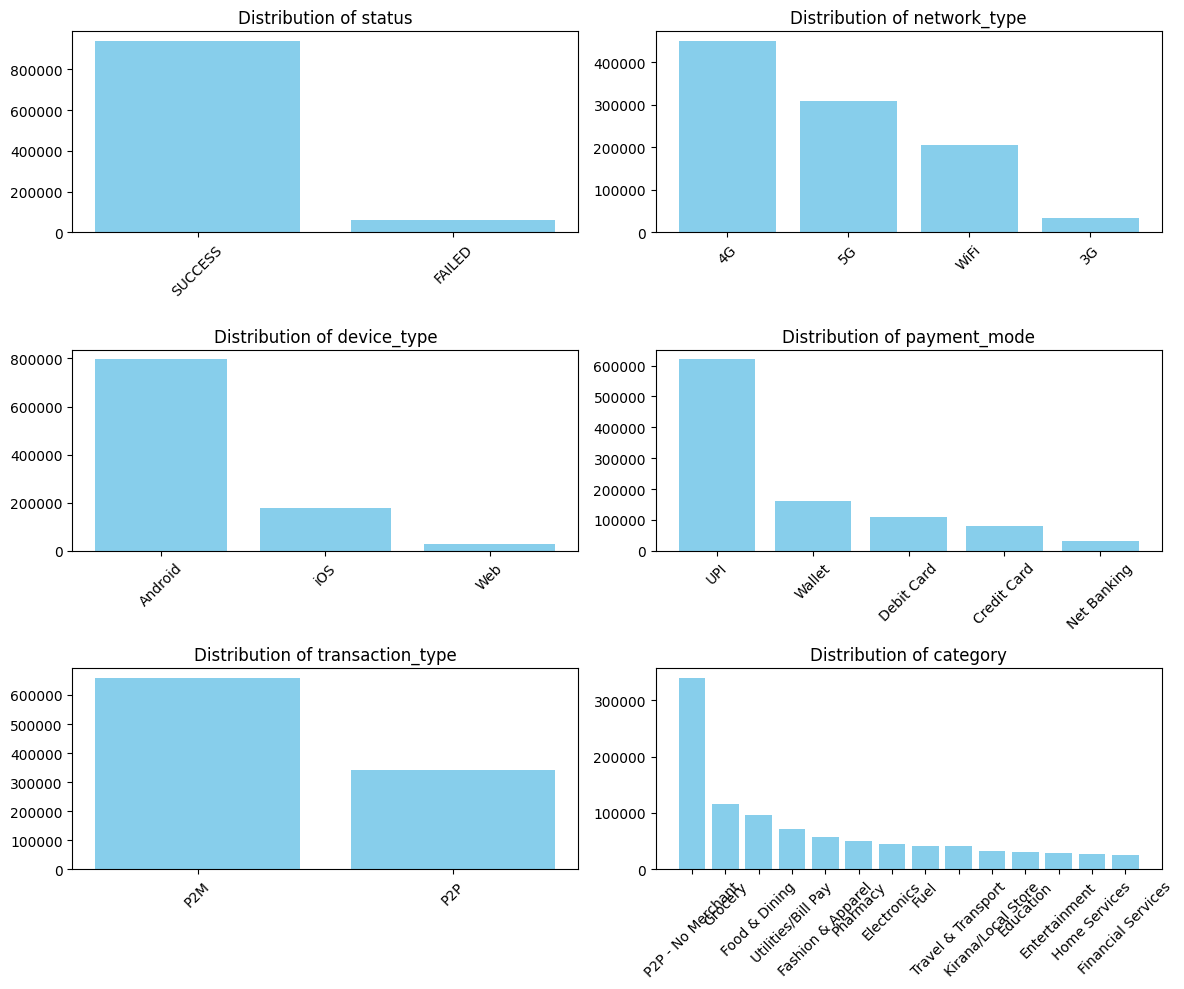

In [7]:
cat_cols = [
    'status',
    'network_type',
    'device_type',
    'payment_mode',
    'transaction_type',
    'category',
]
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten() 
for i, col in enumerate(cat_cols):
  counts = df[col].value_counts()

  axes[i].bar(counts.index.astype(str), counts.values, color='skyblue')
  axes[i].set_title(f'Distribution of {col}')
  axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='is_weekend'>

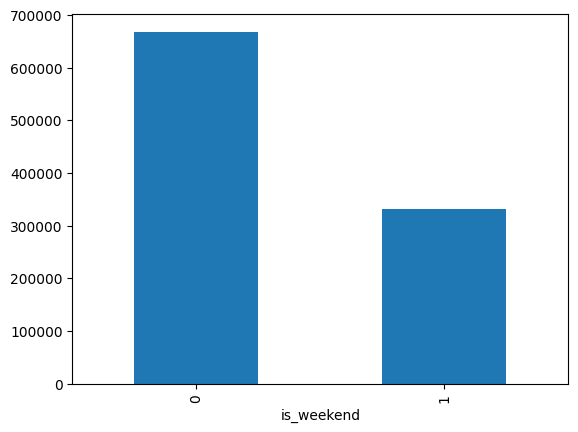

In [8]:
df['is_weekend'].value_counts().plot(kind='bar')

<Axes: xlabel='hour_of_day', ylabel='Count'>

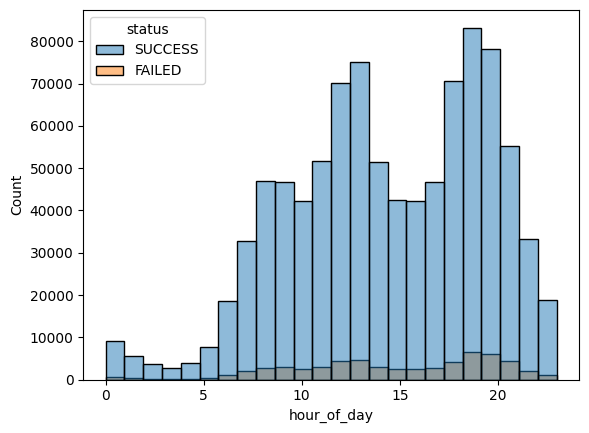

In [9]:
sns.histplot(data=df , x = 'hour_of_day',bins=24,hue='status')

<Axes: xlabel='amount', ylabel='Density'>

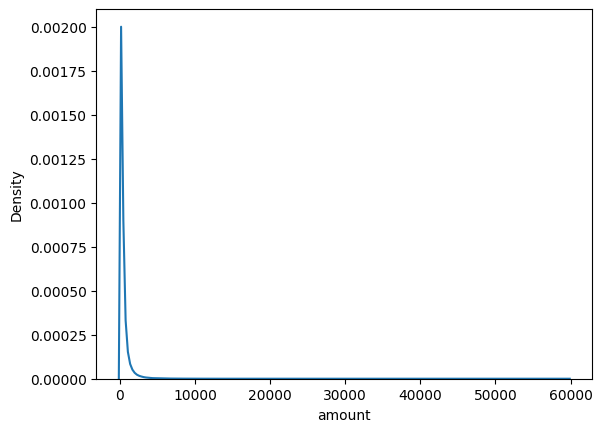

In [10]:
sns.kdeplot(df['amount'])

# Cleaning and Preprocessing

In [53]:
df_cleaned = df.copy()

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df_cleaned['status'] = df_cleaned['status'].map({"SUCCESS" : 0,"FAILED" : 1})

In [14]:
df_cleaned.columns

Index(['transaction_id', 'status', 'network_type', 'device_type',
       'payment_mode', 'transaction_type', 'amount', 'hour_of_day',
       'is_weekend', 'category'],
      dtype='object')

In [57]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['network_type', 'device_type',
       'payment_mode', 'transaction_type','is_weekend', 'category'],drop_first=True)

In [56]:
df_cleaned.drop(columns = 'transaction_id',inplace = True)

In [58]:
df_cleaned.head()

,status,amount,hour_of_day,network_type_4G,network_type_5G,network_type_WiFi,device_type_Web,device_type_iOS,payment_mode_Debit Card,payment_mode_Net Banking,...,category_Financial Services,category_Food & Dining,category_Fuel,category_Grocery,category_Home Services,category_Kirana/Local Store,category_P2P - No Merchant,category_Pharmacy,category_Travel & Transport,category_Utilities/Bill Pay
0,0,156.82,19,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,2055.27,15,False,False,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,0,708.17,11,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,0,424.99,19,False,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,216.88,9,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [18]:
df_cleaned.isnull().sum()

status                         0
amount                         0
hour_of_day                    0
network_type_4G                0
network_type_5G                0
network_type_WiFi              0
device_type_Web                0
device_type_iOS                0
payment_mode_Debit Card        0
payment_mode_Net Banking       0
payment_mode_UPI               0
payment_mode_Wallet            0
transaction_type_P2P           0
is_weekend_1                   0
category_Electronics           0
category_Entertainment         0
category_Fashion & Apparel     0
category_Financial Services    0
category_Food & Dining         0
category_Fuel                  0
category_Grocery               0
category_Home Services         0
category_Kirana/Local Store    0
category_P2P - No Merchant     0
category_Pharmacy              0
category_Travel & Transport    0
category_Utilities/Bill Pay    0
dtype: int64

In [59]:
df_cleaned = df_cleaned.astype(int)

In [60]:
df_cleaned.shape

(1000000, 27)

<Axes: xlabel='amount', ylabel='Density'>

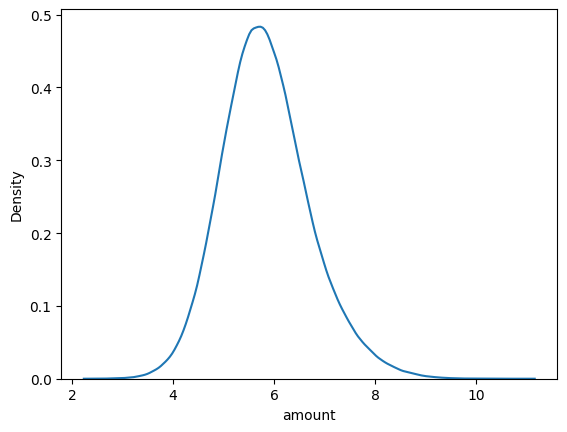

In [21]:
sns.kdeplot(np.log1p(df_cleaned['amount']))

In [61]:
df_cleaned['amount'] = np.log1p(df_cleaned['amount'])

In [63]:
df_cleaned['is_peak_hour'] = df_cleaned['hour_of_day'].isin([19, 20, 21]).astype(int)


# Feature Engineering and Extraction

In [64]:
df_cleaned.columns

Index(['status', 'amount', 'hour_of_day', 'network_type_4G', 'network_type_5G',
       'network_type_WiFi', 'device_type_Web', 'device_type_iOS',
       'payment_mode_Debit Card', 'payment_mode_Net Banking',
       'payment_mode_UPI', 'payment_mode_Wallet', 'transaction_type_P2P',
       'is_weekend_1', 'category_Electronics', 'category_Entertainment',
       'category_Fashion & Apparel', 'category_Financial Services',
       'category_Food & Dining', 'category_Fuel', 'category_Grocery',
       'category_Home Services', 'category_Kirana/Local Store',
       'category_P2P - No Merchant', 'category_Pharmacy',
       'category_Travel & Transport', 'category_Utilities/Bill Pay',
       'is_peak_hour'],
      dtype='object')

In [65]:
#chisqure test

from scipy.stats import chi2_contingency

alpha = 0.05
chi2_results = {}
cat_features = ['network_type_4G', 'network_type_5G',
       'network_type_WiFi', 'device_type_Web', 'device_type_iOS',
       'payment_mode_Debit Card', 'payment_mode_Net Banking',
       'payment_mode_UPI', 'payment_mode_Wallet', 'transaction_type_P2P',
       'is_weekend_1', 'category_Electronics', 'category_Entertainment',
       'category_Fashion & Apparel', 'category_Financial Services',
       'category_Food & Dining', 'category_Fuel', 'category_Grocery',
       'category_Home Services', 'category_Kirana/Local Store',
       'category_P2P - No Merchant', 'category_Pharmacy',
       'category_Travel & Transport', 'category_Utilities/Bill Pay','is_peak_hour']

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['status'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
network_type_5G,1117.548871,0.0,Reject Null (Keep Feature)
is_peak_hour,729.095704,0.0,Reject Null (Keep Feature)
network_type_WiFi,215.250418,0.0,Reject Null (Keep Feature)
network_type_4G,145.846405,0.0,Reject Null (Keep Feature)
device_type_Web,10.675412,0.001086,Reject Null (Keep Feature)
category_Entertainment,4.317743,0.037717,Reject Null (Keep Feature)
is_weekend_1,1.915036,0.166405,Accept Null (Drop Feature)
category_Utilities/Bill Pay,1.286766,0.256645,Accept Null (Drop Feature)
category_Financial Services,1.16876,0.279656,Accept Null (Drop Feature)
category_Pharmacy,0.907537,0.340769,Accept Null (Drop Feature)


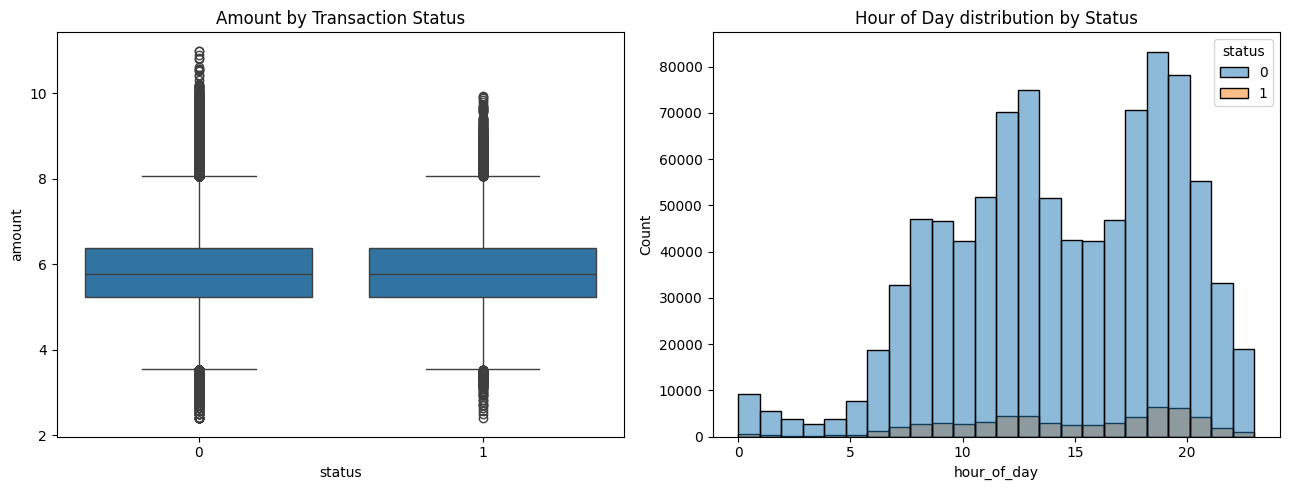

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_cleaned, x='status', y='amount', ax=axes[0])
axes[0].set_title('Amount by Transaction Status')

sns.histplot(data=df_cleaned, x='hour_of_day', hue='status', 
              bins=24, ax=axes[1])
axes[1].set_title('Hour of Day distribution by Status')

plt.tight_layout()
plt.show()


In [69]:
# features that make sense 
feature_cols = ['network_type_5G', 'network_type_WiFi', 'network_type_4G',
                 'device_type_Web', 'hour_of_day', 'is_peak_hour','status']
df_featured = df_cleaned[feature_cols]

In [70]:
df_featured.head()

,network_type_5G,network_type_WiFi,network_type_4G,device_type_Web,hour_of_day,is_peak_hour,status
0,0,1,0,0,19,1,0
1,0,1,0,0,15,0,0
2,1,0,0,0,11,0,0
3,1,0,0,0,19,1,0
4,1,0,0,0,9,0,0


# model selection - logistic regression

In [71]:
X = df_featured.drop('status',axis = 1)
y = df_featured['status']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


In [73]:
scaler = StandardScaler()
X_train[['hour_of_day']] = scaler.fit_transform(X_train[['hour_of_day']])
X_test[['hour_of_day']] = scaler.transform(X_test[['hour_of_day']])

In [74]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [75]:
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1] 

In [76]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[226056  55804]
 [ 12725   5415]]
              precision    recall  f1-score   support

           0       0.95      0.80      0.87    281860
           1       0.09      0.30      0.14     18140

    accuracy                           0.77    300000
   macro avg       0.52      0.55      0.50    300000
weighted avg       0.89      0.77      0.82    300000



In [ ]:
auc = roc_auc_score(y_test, y_probs)       
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.5754


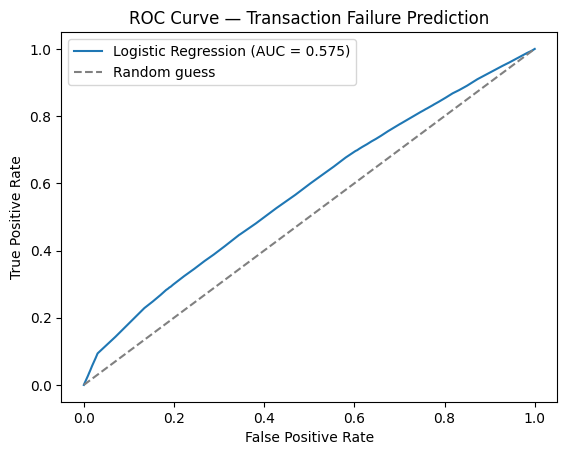

In [78]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Transaction Failure Prediction')
plt.legend(); plt.show()


In [79]:
coef_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': model.coef_[0]}) \
            .sort_values('coefficient', ascending=False)
print(coef_df)

             feature  coefficient
5       is_peak_hour     0.268087
3    device_type_Web    -0.001026
4        hour_of_day    -0.008003
2    network_type_4G    -1.084126
1  network_type_WiFi    -1.263556
0    network_type_5G    -1.370381


In [80]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")

Random Forest ROC-AUC: 0.5732
